In [1]:
from PIL import ImageFile, Image
import os

# Fix corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

def clean_dataset(path):
    for folder in ["Cat", "Dog"]:
        folder_path = os.path.join(path, folder)
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)

path = r"C:\Users\JINESHA GANDHI\Downloads\PetImages\PetImages"
clean_dataset(path)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\JINESHA GANDHI\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [2]:
# Data preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print(train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
{'Cat': 0, 'Dog': 1}


In [3]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(train_data, validation_data=val_data, epochs=3)

# Evaluate
loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

# Predictions
images, labels = next(val_data)
pred = model.predict(images)
pred_labels = (pred > 0.5).astype(int).flatten()

class_names = list(train_data.class_indices.keys())

C:\Users\JINESHA GANDHI\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
 84/625 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step - accuracy: 0.5055 - loss: 0.7255

C:\Users\JINESHA GANDHI\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.6460 - loss: 0.6222 - val_accuracy: 0.7357 - val_loss: 0.5321
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.7595 - loss: 0.4971 - val_accuracy: 0.7533 - val_loss: 0.4877
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.8010 - loss: 0.4276 - val_accuracy: 0.7913 - val_loss: 0.4433
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.7913 - loss: 0.4433
Accuracy: 0.7913165092468262
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


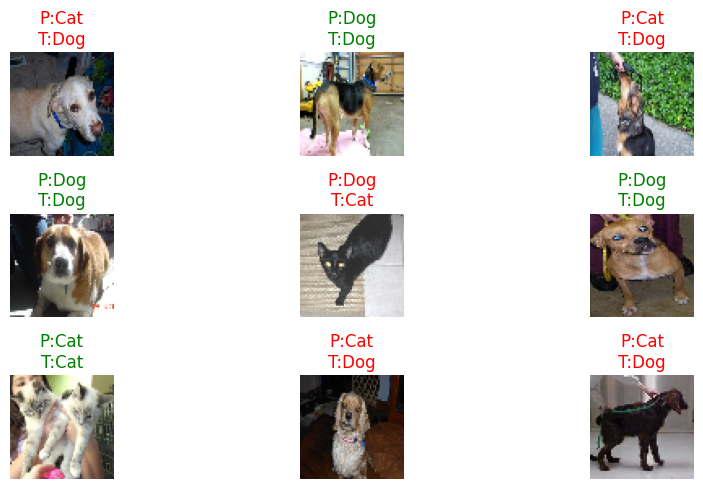

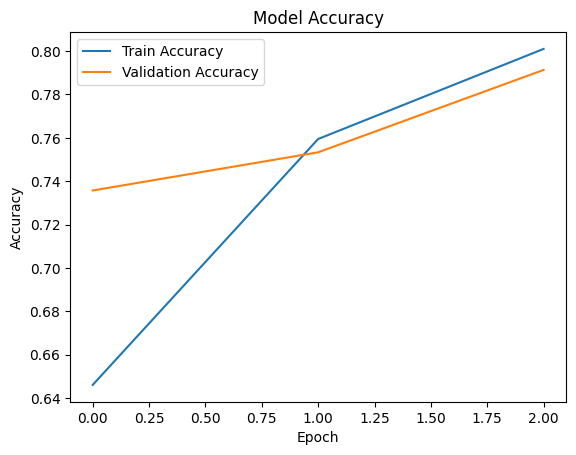

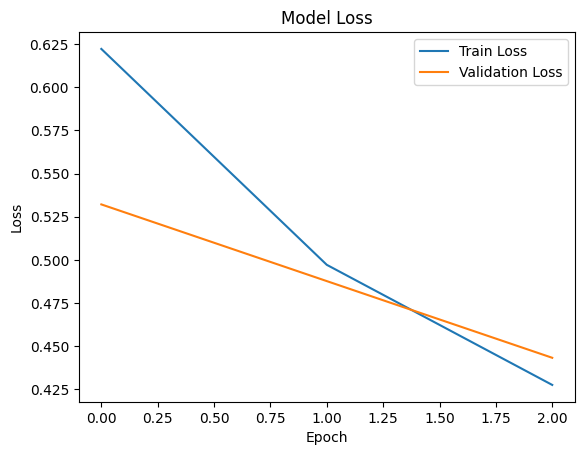

In [4]:
# Display predictions
plt.figure(figsize=(10,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    p = class_names[int(pred_labels[i])]
    t = class_names[int(labels[i])]
    color = 'green' if p == t else 'red'
    plt.title(f"P:{p}\nT:{t}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
